In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#loading the datset

In [3]:
#creating the database connection
conn=sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,100.0,3599.00,647.82,183.74,68601.68,-3807652.60,-1.057975e+05,0.000689,0.000944
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,35.0,1049.65,539.82,64.31,144929.24,-3802991.57,-3.623104e+05,0.000213,0.000276
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,0.0,0.00,0.00,0.00,123780.22,-3418303.68,-inf,0.000000,0.000000
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,0.0,0.00,0.00,0.00,257032.07,-3261197.94,-inf,0.000000,0.000000
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,34.0,1025.66,513.83,62.45,257032.07,-3022180.35,-2.946571e+05,0.000246,0.000339


In [4]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.0000,7153.000,9552.0000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.5000,18761.500,25514.2500,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.8400,10.455,19.4825,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.9900,15.990,28.9900,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.0000,750.000,750.0000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.0000,262.000,1975.7500,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.4575,3655.465,20738.2450,3.811252e+06
TotalSalesQuantity,10692.0,7.671156e-01,5.080036,0.00,0.0000,0.000,0.0000,1.550000e+02
TotalSalesDollars,10692.0,1.019776e+01,75.391960,0.00,0.0000,0.000,0.0000,3.599000e+03
TotalSalesPrice,10692.0,5.227425e+00,30.015302,0.00,0.0000,0.000,0.0000,6.508100e+02


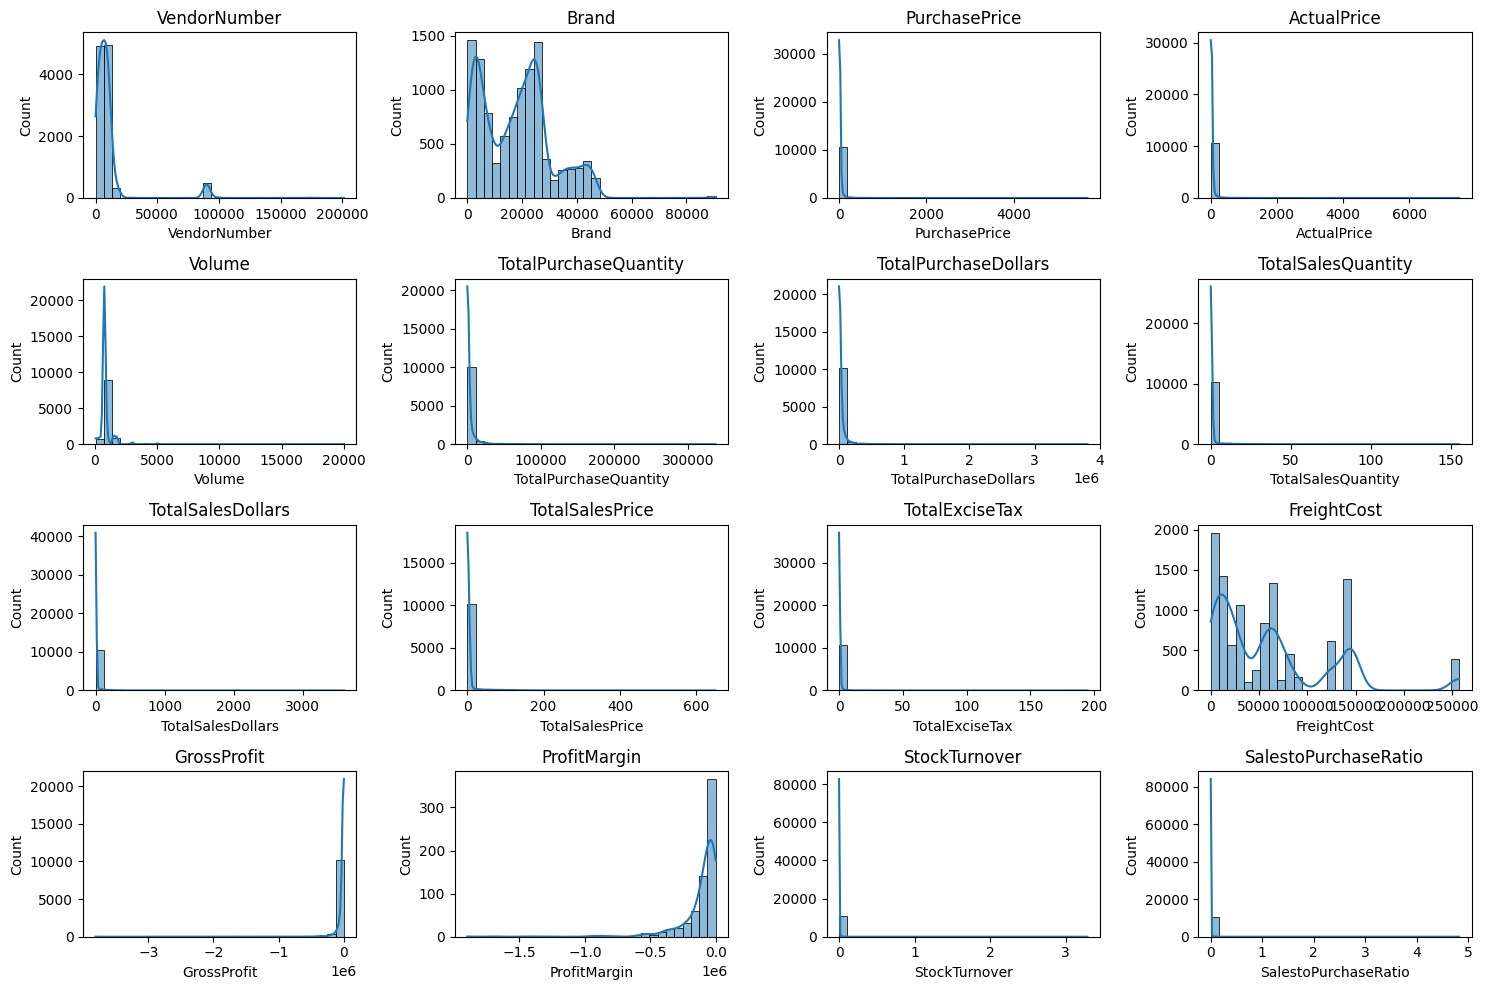

In [5]:
#distribution plot for numerical columns


numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) #adjust grid plot as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

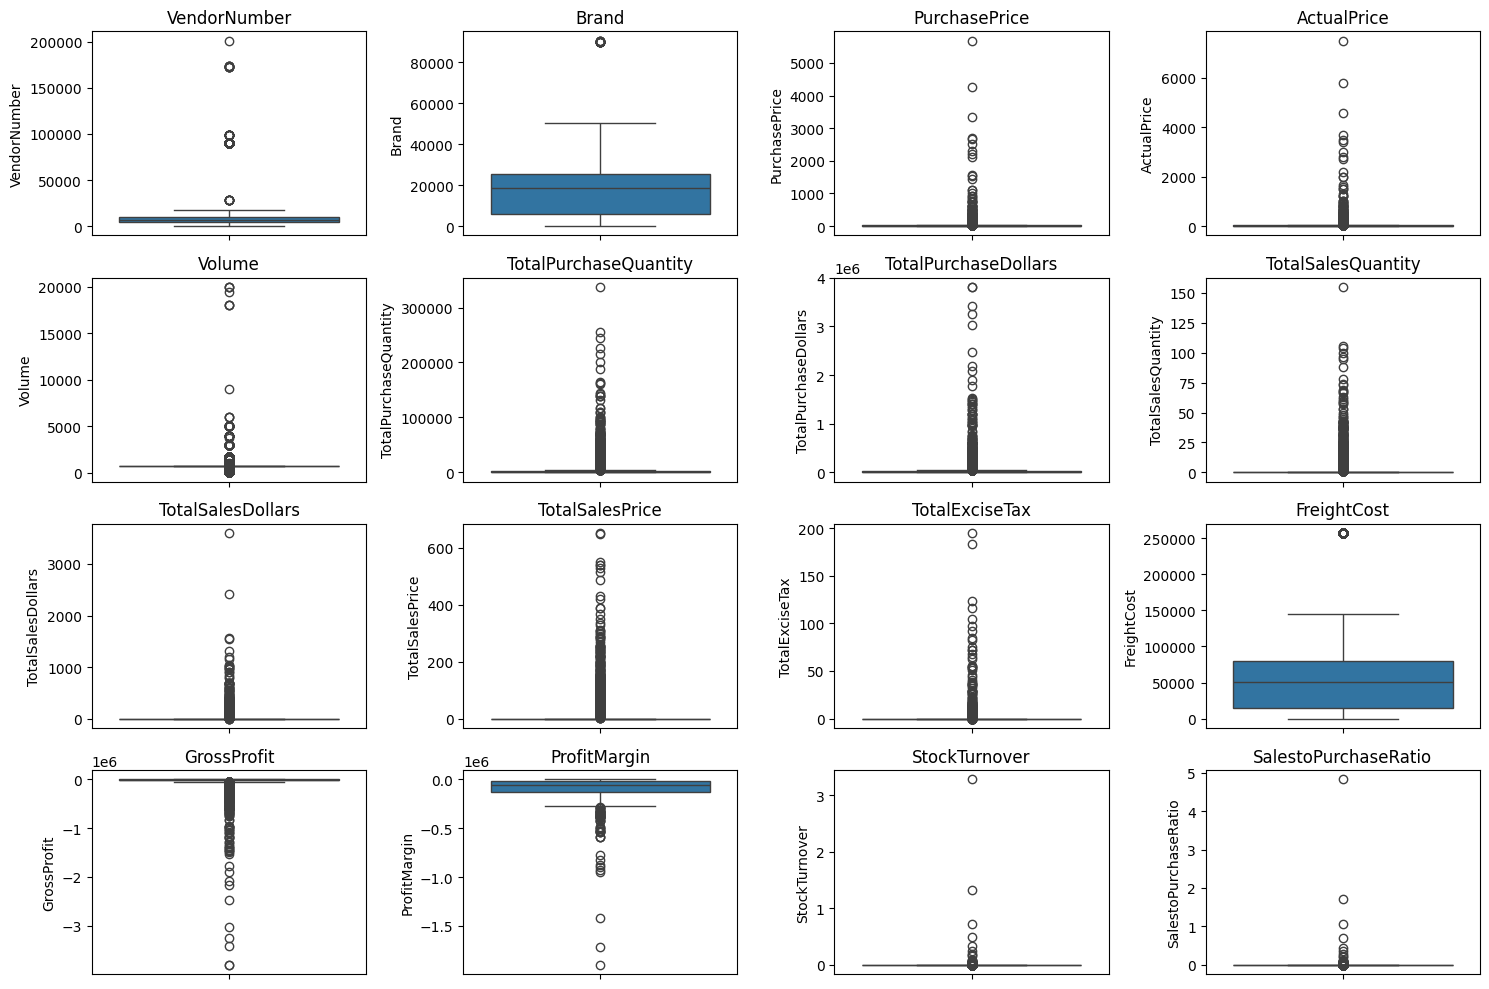

In [6]:
#outlier detection with boxplot

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) 
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [7]:
#lets filter the data by removing inconsistencies
df=pd.read_sql_query(""" SELECT * FROM vendor_sales_summary
WHERE  GrossProfit>0
AND ProfitMargin>0
AND TotalSalesQuantity>0""",conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,90024,VINILANDIA USA,16370,Zinsane Znfdl Lodi,5.44,7.99,750.0,44,239.36,32.0,255.68,143.82,3.55,2802.64,16.32,6.382979,0.727273,1.068182
1,3252,E & J GALLO WINERY,14620,Bodega Elena de Mendoza Mlbc,4.76,6.99,750.0,7,33.32,23.0,160.77,48.93,2.57,61966.91,127.45,79.274740,3.285714,4.825030
2,12546,JIM BEAM BRANDS COMPANY,1035,Pinnacle Vodka Gift Pak,8.59,12.99,750.0,3,25.77,4.0,43.96,32.97,3.15,123880.97,18.19,41.378526,1.333333,1.705860


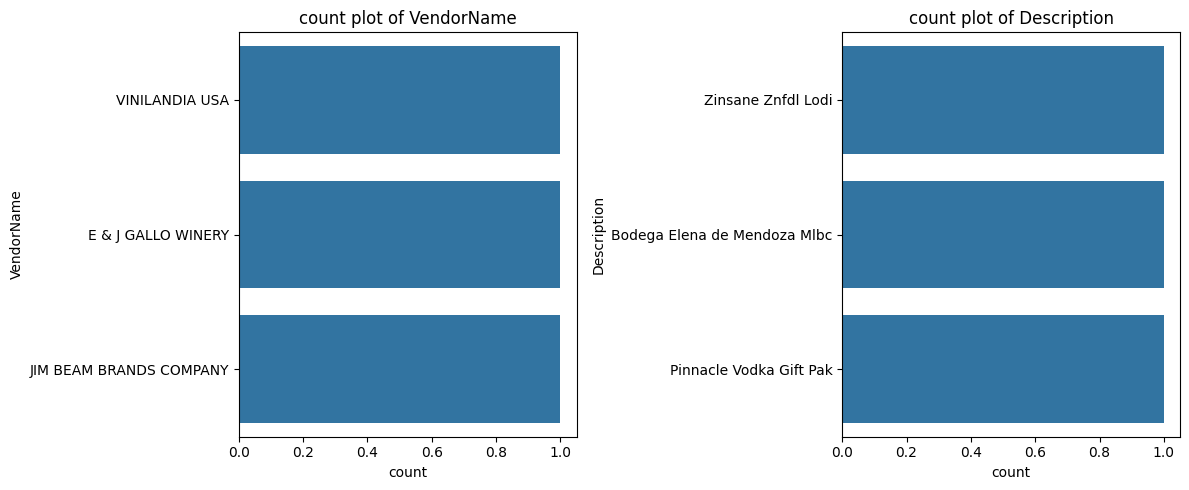

In [9]:
#count plot for categorical columns
categorical_cols=["VendorName","Description"]

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1) 
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) #top 10 categories
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

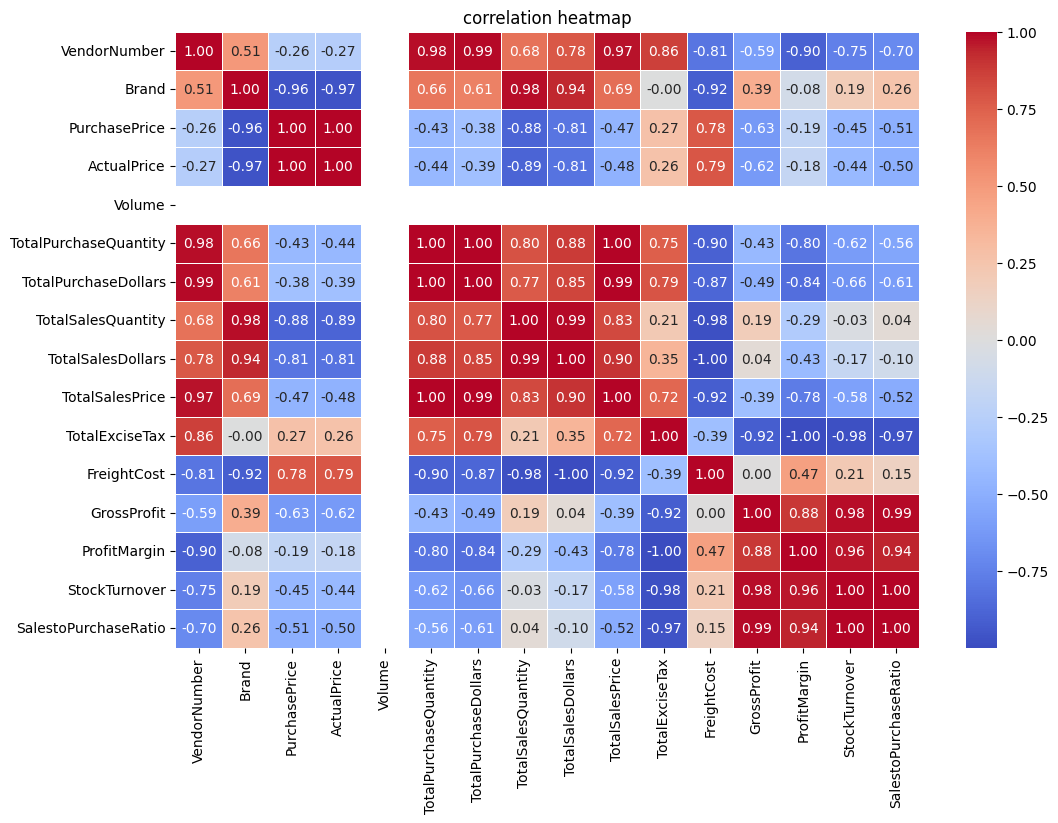

In [10]:
#correlation heatmap
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("correlation heatmap")
plt.show()

In [11]:
#identify the brands that need promotional or pricing  adjustmenst with exhibit lower sales performance but higher profit margin
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [12]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,Bodega Elena de Mendoza Mlbc,160.77,79.274740
1,Pinnacle Vodka Gift Pak,43.96,41.378526
2,Zinsane Znfdl Lodi,255.68,6.382979


In [13]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [14]:
low_sales_threshold

np.float64(79.003)

In [15]:
high_margin_threshold

np.float64(67.90587599837293)

In [16]:
#filter brands with low sales but high performance
target_brands=brand_performance[
    (brand_performance['TotalSalesDollars']<=low_sales_threshold)&
    (brand_performance['ProfitMargin']>=high_margin_threshold)
]
print("Brands with low sales but high profit margins")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins


,Description,TotalSalesDollars,ProfitMargin


In [17]:
#which vendor and brand demonstarte the highest sales performance?

In [18]:
def format_dollars(value):
    if value>=1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)


In [19]:
#top vendors & brands by sales performace
top_vendors=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)    

In [20]:
top_vendors

VendorName
VINILANDIA USA             255.68
E & J GALLO WINERY         160.77
JIM BEAM BRANDS COMPANY     43.96
Name: TotalSalesDollars, dtype: float64

In [21]:
top_brands.apply(lambda x:format_dollars(x))

Description
Zinsane Znfdl Lodi              255.68
Bodega Elena de Mendoza Mlbc    160.77
Pinnacle Vodka Gift Pak          43.96
Name: TotalSalesDollars, dtype: str

In [22]:
top_brands

Description
Zinsane Znfdl Lodi              255.68
Bodega Elena de Mendoza Mlbc    160.77
Pinnacle Vodka Gift Pak          43.96
Name: TotalSalesDollars, dtype: float64

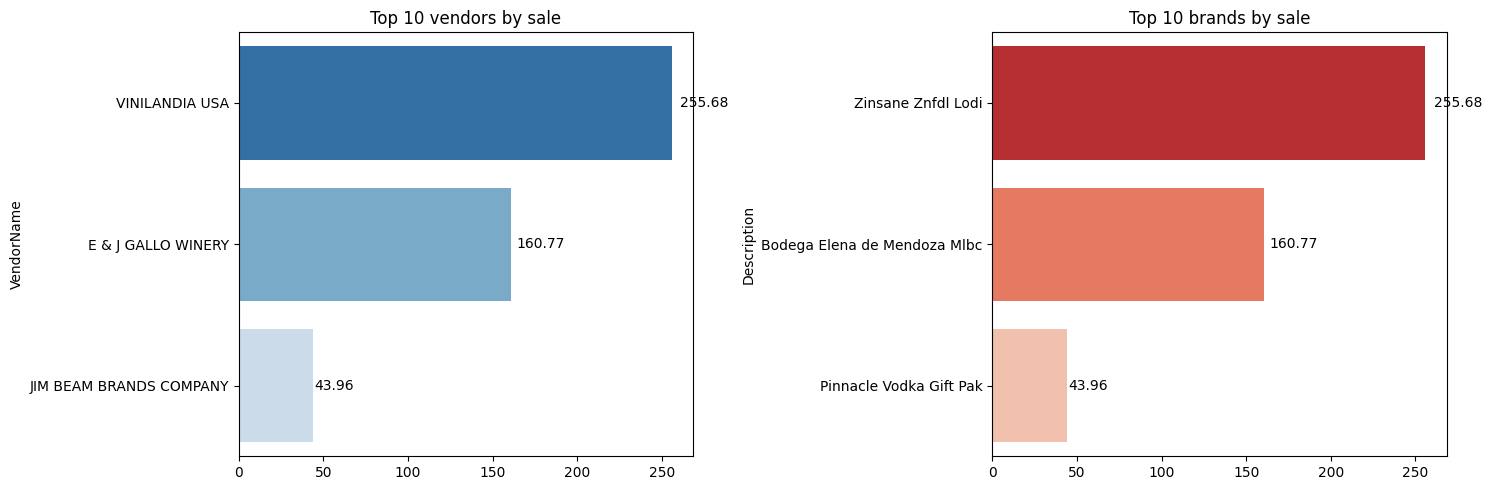

In [23]:
#plot for top vendors
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
ax1=sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")
plt.title("Top 10 vendors by sale")

for bar in ax1.patches:
    ax1.text(bar.get_width()+ (bar.get_width()*0.02),
             bar.get_y()+bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left',va='center',fontsize=10,color='black')

#plot for top brands
plt.subplot(1,2,2)
ax2=sns.barplot(y=top_brands.index,x=top_brands.values,palette="Reds_r")
plt.title("Top 10 brands by sale")

for bar in ax2.patches:
    ax2.text(bar.get_width()+ (bar.get_width()*0.02),
             bar.get_y()+bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left',va='center',fontsize=10,color='black')

plt.tight_layout()
plt.show()

In [24]:
#which vendor contributre the most to total purchase dollars?
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [25]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [26]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [27]:
#display top 10 vendors
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
2,VINILANDIA USA,239.36,16.32,255.68,80.20
0,E & J GALLO WINERY,33.32,127.45,160.77,11.16
1,JIM BEAM BRANDS COMPANY,25.77,18.19,43.96,8.63


In [28]:
top_vendors['PurchaseContribution%'].sum()

np.float64(99.99)

In [29]:
top_vendors['Cumulative_contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_contribution%
2,VINILANDIA USA,239.36,16.32,255.68,80.20,80.20
0,E & J GALLO WINERY,33.32,127.45,160.77,11.16,91.36
1,JIM BEAM BRANDS COMPANY,25.77,18.19,43.96,8.63,99.99


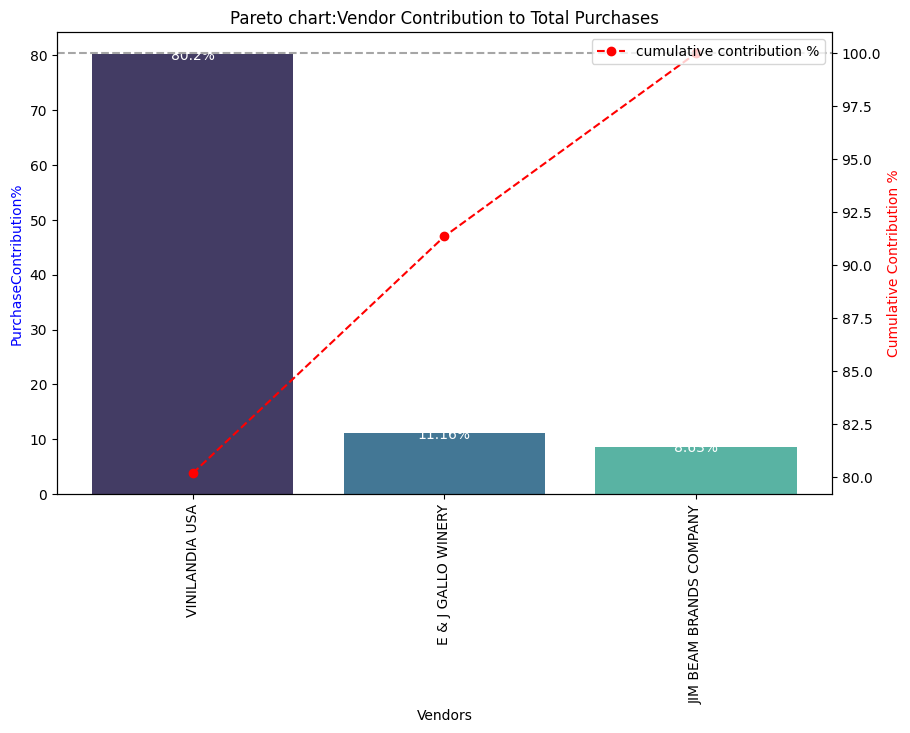

In [30]:
fig,ax1=plt.subplots(figsize=(10,6))

#bar plot for purchase contribution
sns.barplot(x=top_vendors['VendorName'],y=top_vendors['PurchaseContribution%'], palette='mako',ax=ax1)

for i,value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value-1 , str(value)+'%' ,ha='center',fontsize=10,color='white')

#line plot for cummulative purchase
ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'],top_vendors['Cumulative_contribution%'],color='red',marker='o',linestyle='dashed',label='cumulative contribution %')

ax1.set_xticklabels(top_vendors['VendorName'],rotation=90)
ax1.set_ylabel('PurchaseContribution%',color='blue')
ax2.set_ylabel('Cumulative Contribution %',color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto chart:Vendor Contribution to Total Purchases')

ax2.axhline(y=100,color='gray',linestyle='dashed',alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

In [31]:
#how much of total_procurement is dependent on vendor performance?

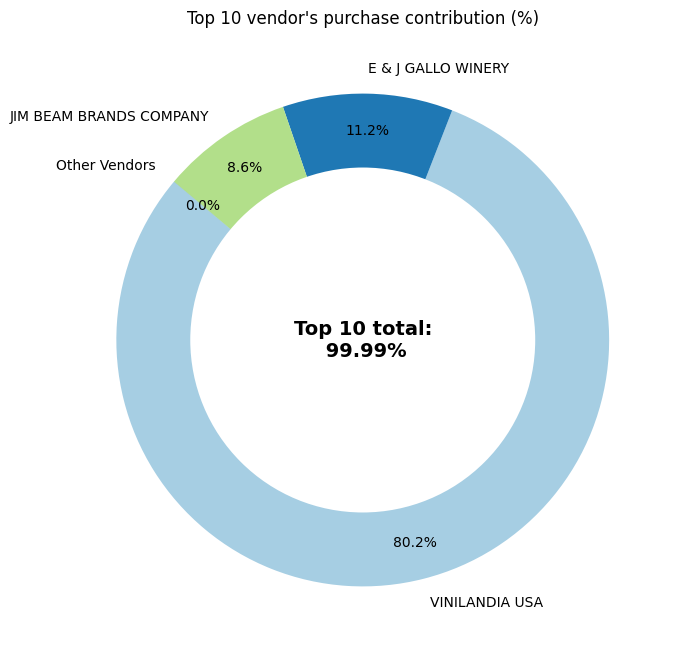

In [32]:
vendors=list(top_vendors['VendorName'].values)
purchase_contributions=list(top_vendors['PurchaseContribution%'].values)
total_contribution=sum(purchase_contributions)
remaining_contribution=100-total_contribution

#append "other vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

#donut chart
fig,ax=plt.subplots(figsize=(8,8))
wedegs,texts,autotexts=ax.pie(purchase_contributions,labels=vendors,autopct='%1.1f%%',startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)

#draw a white circle in the center to create a donut effect
center_circle=plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(center_circle)


#add total contribution annotation in the center
plt.text(0,0,f"Top 10 total:\n{total_contribution : .2f}%",fontsize=14,fontweight='bold',ha='center',va='center')
plt.title("Top 10 vendor's purchase contribution (%)") 
plt.show()


In [33]:
#does purchasing in bulk reduce the unit price and what is the optimal purchase volume for cost savings?

In [34]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [35]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice
0,90024,VINILANDIA USA,16370,Zinsane Znfdl Lodi,5.44,7.99,750.0,44,239.36,32.0,255.68,143.82,3.55,2802.64,16.32,6.382979,0.727273,1.068182,5.44
1,3252,E & J GALLO WINERY,14620,Bodega Elena de Mendoza Mlbc,4.76,6.99,750.0,7,33.32,23.0,160.77,48.93,2.57,61966.91,127.45,79.274740,3.285714,4.825030,4.76
2,12546,JIM BEAM BRANDS COMPANY,1035,Pinnacle Vodka Gift Pak,8.59,12.99,750.0,3,25.77,4.0,43.96,32.97,3.15,123880.97,18.19,41.378526,1.333333,1.705860,8.59


In [36]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=["Small","Medium","Large"])

In [37]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,8.59
Medium,4.76
Large,5.44


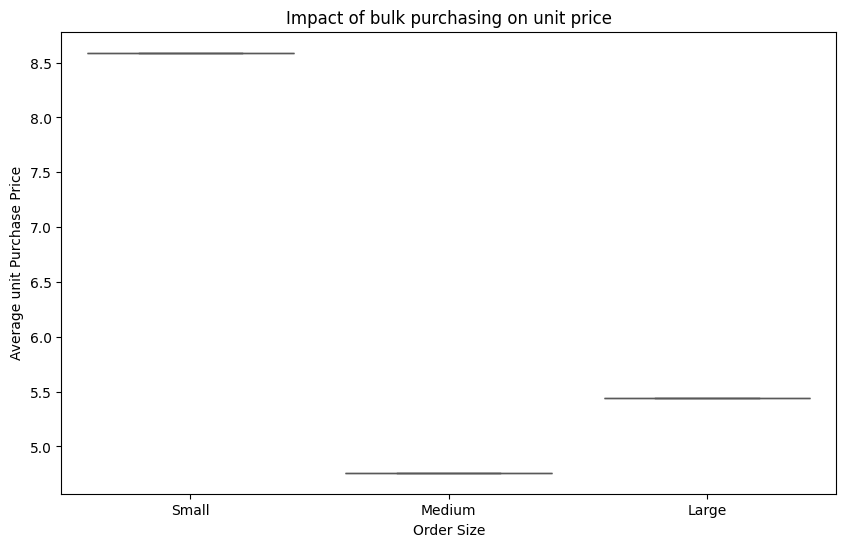

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="OrderSize",y="UnitPurchasePrice",palette="Set2")
plt.title("Impact of bulk purchasing on unit price")
plt.xlabel("Order Size")
plt.ylabel("Average unit Purchase Price")
plt.show()

In [39]:
#which vendor have low vendor turnover,indicating excess stock and slow moving products?
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean()

,StockTurnover
VendorName,
VINILANDIA USA,0.727273


In [40]:
#how much capital is locked in unsold inventory per vendor and which vendor contribute the most to it?
df["UnsoldInventoryValue"]=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
print("Total Unsold Capital:",format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: -19.469999999999995


In [41]:
#what is the 95% confidence interval for profit margins of top performing and low performing vendors?
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

In [42]:
top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()

In [43]:
top_vendors

0    6.382979
Name: ProfitMargin, dtype: float64

In [44]:
low_vendors

2    41.378526
Name: ProfitMargin, dtype: float64

In [45]:
def confidence_interval(data,confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data))  #standing error
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_val,mean_val-margin_of_error,mean_val+margin_of_error

Top Vendors 95% CI:(nan,nan,Mean:6.38
Low Vendors 95% CI:(nan,nan,Mean:41.38


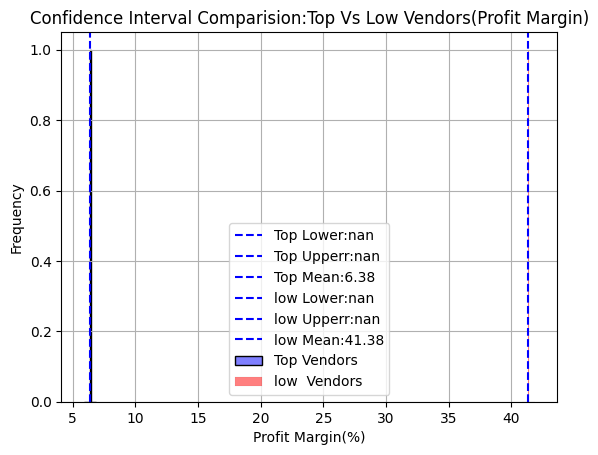

In [46]:
top_mean,top_lower,top_upper=confidence_interval(top_vendors)
low_mean,low_lower,low_upper=confidence_interval(low_vendors)

print(f"Top Vendors 95% CI:({top_lower:.2f},{top_upper:.2f},Mean:{top_mean:.2f}")
print(f"Low Vendors 95% CI:({low_lower:.2f},{low_upper:.2f},Mean:{low_mean:.2f}")

#top vendors plot
sns.histplot(top_vendors,kde=True,color="blue",bins=30,alpha=0.5,label='Top Vendors')
plt.axvline(top_lower,color="blue",linestyle="--",label=f"Top Lower:{top_lower:.2f}")
plt.axvline(top_upper,color="blue",linestyle="--",label=f"Top Upperr:{top_upper:.2f}")
plt.axvline(top_mean,color="blue",linestyle="--",label=f"Top Mean:{top_mean:.2f}")

#low vendors plot
sns.histplot(low_vendors,kde=True,color="red",bins=30,alpha=0.5,label='low  Vendors')
plt.axvline(low_lower,color="blue",linestyle="--",label=f"low Lower:{low_lower:.2f}")
plt.axvline(low_upper,color="blue",linestyle="--",label=f"low Upperr:{low_upper:.2f}")
plt.axvline(low_mean,color="blue",linestyle="--",label=f"low Mean:{low_mean:.2f}")

#finalise plot
plt.title("Confidence Interval Comparision:Top Vs Low Vendors(Profit Margin)")
plt.xlabel("Profit Margin(%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
           

In [50]:
df=pd.read_sql_query("SELECT * FROM vendor_sales_summary",conn)

In [52]:
df.to_csv('vendor_sales_summary.csv', index=False)
